In [ ]:
#  Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import calendar

# Set Seaborn theme for clean visuals
sns.set_theme(style="whitegrid", palette="viridis")


# Load CSV
df = pd.read_csv("household_data.csv")
df.head(3)

,house_size_marla,num_residents,working_residents,urban_rural,energy_saving_appliances,weekend,month,temperature,num_lights,hours_lights,...,num_microwave,hours_microwave,num_iron,hours_iron,num_water_pump,hours_water_pump,total_appliances,avg_daily_kwh,kwh_per_resident,monthly_kwh
0,13,7,1,Rural,0,0,6,35.4,8,4.6,...,1,0.9,0,0.8,1,2.6,26,99.4,426.2,2983.1
1,75,7,3,Urban,0,0,6,32.9,11,4.3,...,1,1.6,1,0.8,0,1.9,33,67.3,288.6,2020.4
2,33,7,2,Urban,0,0,8,30.5,24,4.0,...,1,1.8,1,0.5,1,1.9,43,56.0,240.1,1680.8


In [24]:
# Basic dataset overview
print("Dataset Shape:", df.shape)
print("\n--- Dataset Info ---")
print(df.info())

Dataset Shape: (15000, 35)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   house_size_marla          15000 non-null  int64  
 1   num_residents             15000 non-null  int64  
 2   working_residents         15000 non-null  int64  
 3   urban_rural               15000 non-null  object 
 4   energy_saving_appliances  15000 non-null  int64  
 5   weekend                   15000 non-null  int64  
 6   month                     15000 non-null  int64  
 7   temperature               15000 non-null  float64
 8   num_lights                15000 non-null  int64  
 9   hours_lights              15000 non-null  float64
 10  num_fans                  15000 non-null  int64  
 11  hours_fans                15000 non-null  float64
 12  num_AC                    15000 non-null  int64  
 13  hours_AC    

In [25]:
# Check for duplicates
print("\nNumber of Duplicate Rows:", df.duplicated().sum())


Number of Duplicate Rows: 0


In [26]:
# Summary statistics
df.describe(include='all')

,house_size_marla,num_residents,working_residents,urban_rural,energy_saving_appliances,weekend,month,temperature,num_lights,hours_lights,...,num_microwave,hours_microwave,num_iron,hours_iron,num_water_pump,hours_water_pump,total_appliances,avg_daily_kwh,kwh_per_resident,monthly_kwh
count,15000.000000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Urban,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,11272,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,26.449467,5.511133,1.993133,NaN,0.303933,0.287800,6.530933,26.217647,15.541867,5.509820,...,1.002000,0.998493,0.498267,0.497160,0.498800,1.502767,34.265400,56.226647,341.500173,1686.798800
std,21.640644,1.708431,0.816372,NaN,0.459970,0.452752,3.438114,8.141502,5.061234,1.440948,...,0.708258,0.579331,0.500014,0.290175,0.500015,0.867152,7.472529,28.088411,217.066514,842.645592
min,0.000000,3.000000,1.000000,NaN,0.000000,0.000000,1.000000,5.000000,5.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,6.200000,25.500000,185.400000
25%,9.000000,4.000000,1.000000,NaN,0.000000,0.000000,4.000000,19.300000,12.000000,4.300000,...,1.000000,0.500000,0.000000,0.200000,0.000000,0.700000,29.000000,35.200000,186.875000,1054.775000
50%,19.000000,6.000000,2.000000,NaN,0.000000,0.000000,7.000000,27.700000,16.000000,5.500000,...,1.000000,1.000000,0.000000,0.500000,0.000000,1.500000,34.000000,51.700000,289.400000,1551.850000
75%,39.000000,7.000000,3.000000,NaN,1.000000,1.000000,10.000000,33.000000,20.000000,6.700000,...,2.000000,1.500000,1.000000,0.700000,1.000000,2.300000,40.000000,72.400000,437.325000,2171.550000


In [27]:
# Define bins and labels
bins = [0, 10, 20, 30, 50, 100]   # adjust upper limit if needed
labels = ['0-10', '10-20', '20-30', '30-50', '50+']

# Create a new column with house size ranges
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)

# Unique value counts for categorical-like columns
for col in ['city', 'house_size_group', 'month']:
    if col in df.columns:
        print(f"\nUnique values in '{col}':")
        print(df[col].unique())



Unique values in 'house_size_group':
['10-20', '50+', '30-50', '20-30', '0-10']
Categories (5, object): ['0-10' < '10-20' < '20-30' < '30-50' < '50+']

Unique values in 'month':
[ 6  8  1  4 11  9 10  7  2  3  5 12]


In [28]:
size_order = {'0-5':1, '5-10':2, '10-15':3, '15-20':4, '20-30':5, '30-40':6, '40-50':7, '50-60':8, '60-70':9, '70-80':10}
df['house_size_numeric'] = df['house_size_marla'].map(size_order)

In [29]:
features = ['house_size_numeric', 'num_residents', 'month', 'temperature',
            'num_lights', 'hours_lights', 'num_fans', 'hours_fans',
            'num_AC', 'hours_AC', 'num_fridge', 'num_washing_machine',
            'hours_washing_machine', 'num_TV', 'hours_TV',
            'num_computer', 'hours_computer', 'num_water_heater', 'hours_water_heater']

target = 'monthly_kwh'

X = df[features]
y = df[target]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred),2))
print("MSE:", round(mean_squared_error(y_test, y_pred),2))
print("R2:", round(r2_score(y_test, y_pred),4))

MAE: 151.64
MSE: 38945.63
R2: 0.9441


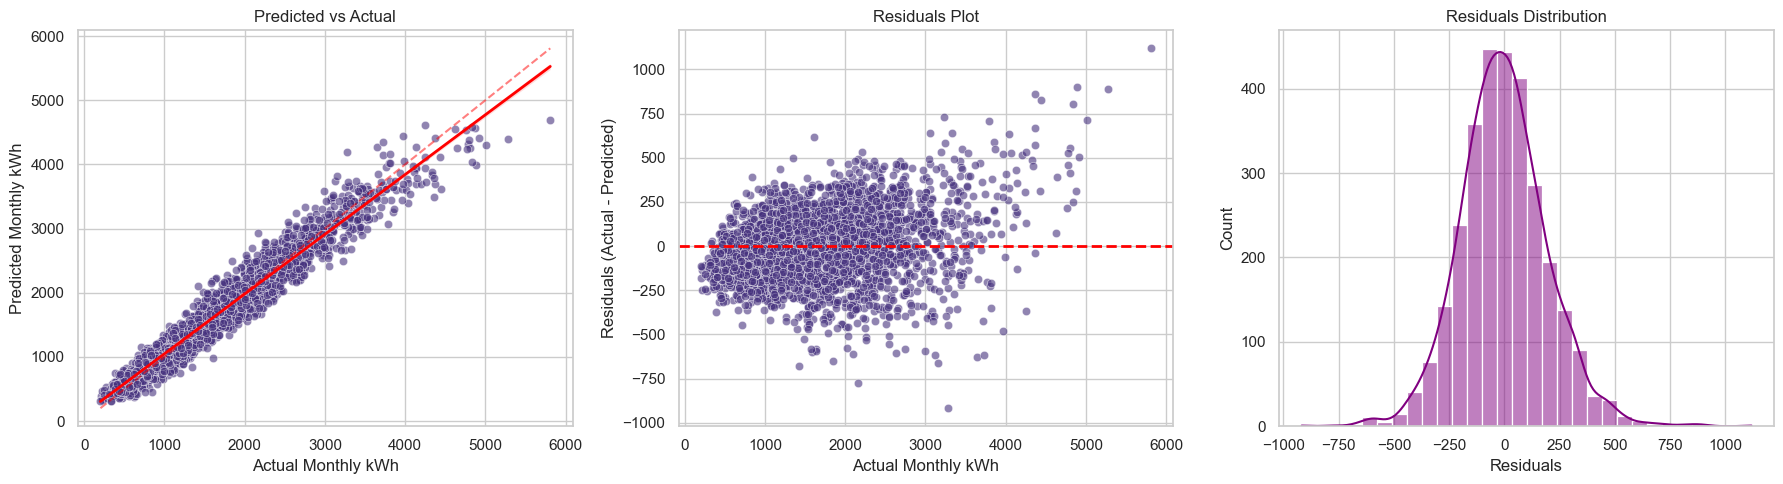

In [32]:
# Assume y_test = actual values, y_pred = model predictions
residuals = y_test - y_pred

plt.figure(figsize=(18,5))

# ------------------- Plot 1: Predicted vs Actual -------------------
plt.subplot(1,3,1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red', line_kws={'lw':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)
plt.xlabel("Actual Monthly kWh")
plt.ylabel("Predicted Monthly kWh")
plt.title("Predicted vs Actual")

# ------------------- Plot 2: Residuals -------------------
plt.subplot(1,3,2)
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Actual Monthly kWh")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot")

# ------------------- Plot 3: Residuals Distribution -------------------
plt.subplot(1,3,3)
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.title("Residuals Distribution")

plt.tight_layout()
plt.show()

C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3960743597.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance, y=feat_importance.index, palette="viridis")


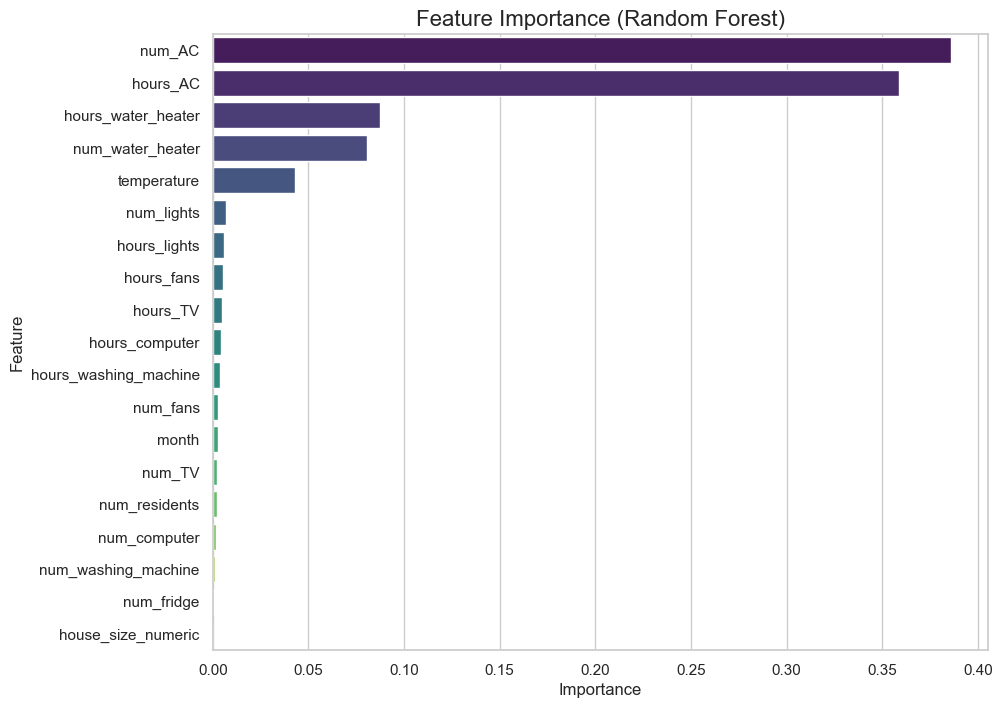

In [33]:
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=feat_importance, y=feat_importance.index, palette="viridis")
plt.title("Feature Importance (Random Forest)", fontsize=16)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [34]:
print(df.columns)

Index(['house_size_marla', 'num_residents', 'working_residents', 'urban_rural',
       'energy_saving_appliances', 'weekend', 'month', 'temperature',
       'num_lights', 'hours_lights', 'num_fans', 'hours_fans', 'num_AC',
       'hours_AC', 'num_fridge', 'num_washing_machine',
       'hours_washing_machine', 'num_TV', 'hours_TV', 'num_computer',
       'hours_computer', 'num_water_heater', 'hours_water_heater', 'num_oven',
       'hours_oven', 'num_microwave', 'hours_microwave', 'num_iron',
       'hours_iron', 'num_water_pump', 'hours_water_pump', 'total_appliances',
       'avg_daily_kwh', 'kwh_per_resident', 'monthly_kwh', 'house_size_group',
       'house_size_numeric'],
      dtype='object')


In [35]:
# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
house_size_marla                0
num_residents                   0
working_residents               0
urban_rural                     0
energy_saving_appliances        0
weekend                         0
month                           0
temperature                     0
num_lights                      0
hours_lights                    0
num_fans                        0
hours_fans                      0
num_AC                          0
hours_AC                        0
num_fridge                      0
num_washing_machine             0
hours_washing_machine           0
num_TV                          0
hours_TV                        0
num_computer                    0
hours_computer                  0
num_water_heater                0
hours_water_heater              0
num_oven                        0
hours_oven                      0
num_microwave                   0
hours_microwave                 0
num_iron                        0
hours_iron      

C:\Users\mando\AppData\Local\Temp\ipykernel_6128\568391779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='house_size_group', y='monthly_kwh', data=df, palette="viridis")


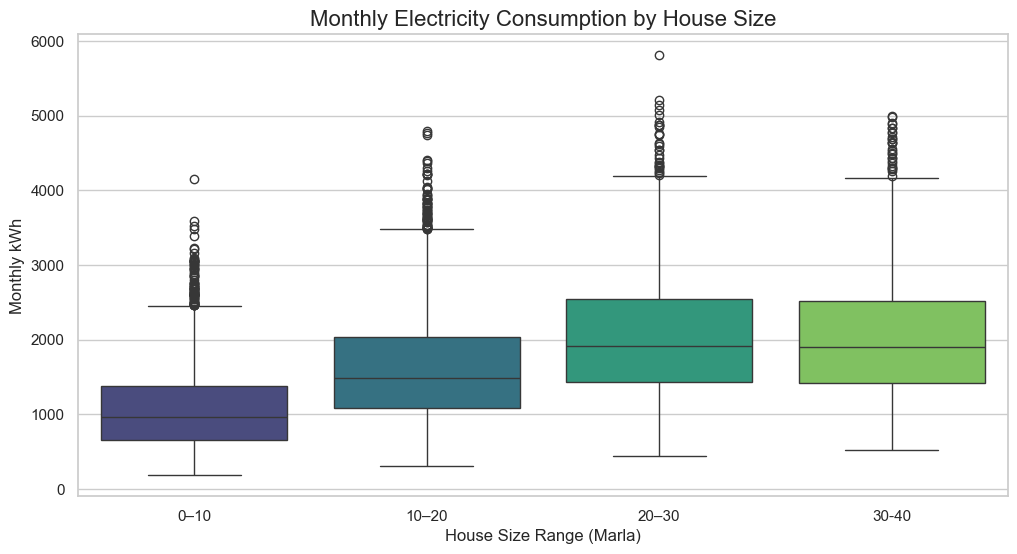

In [36]:
bins = [0, 10, 20, 30, 40]
labels = ['0–10', '10–20', '20–30', '30-40']
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, right=False)
df = df.dropna(subset=['house_size_group', 'monthly_kwh'])

plt.figure(figsize=(12,6))
sns.boxplot(x='house_size_group', y='monthly_kwh', data=df, palette="viridis")
plt.title("Monthly Electricity Consumption by House Size", fontsize=16)
plt.ylabel("Monthly kWh")
plt.xlabel("House Size Range (Marla)")
plt.show()

C:\Users\mando\AppData\Local\Temp\ipykernel_6128\393975272.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_month_group = df.groupby(['month', 'house_size_group'])['monthly_kwh'].mean().reset_index()


<Figure size 1200x600 with 0 Axes>

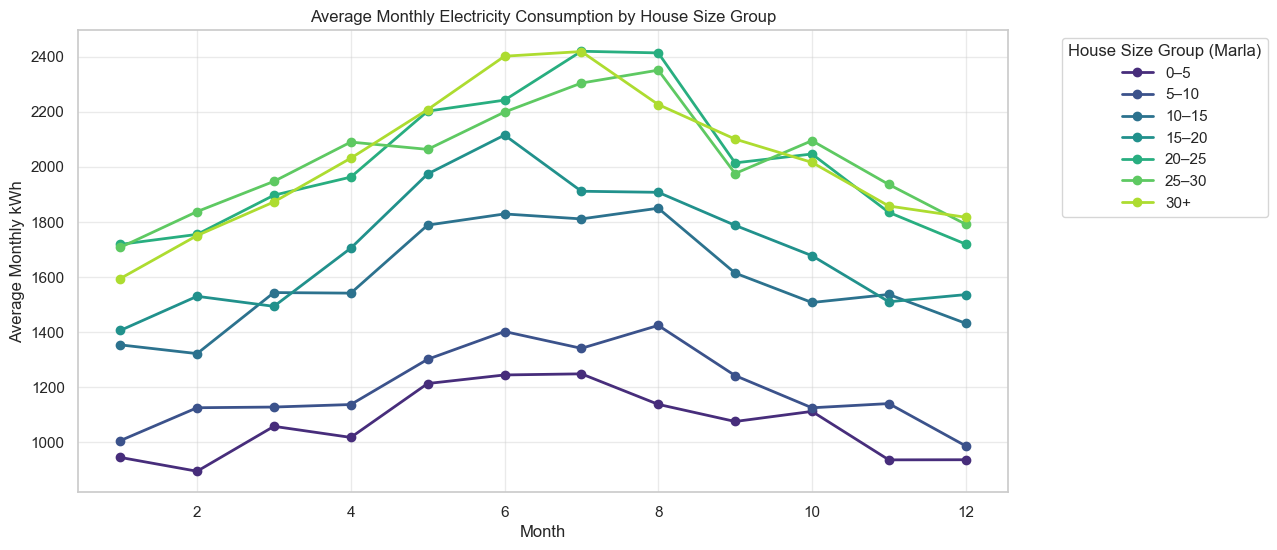

In [37]:
df['house_size_marla'] = pd.to_numeric(df['house_size_marla'], errors='coerce')


bins = [0, 5, 10, 15, 20, 25, 30, 50]
labels = ['0–5', '5–10', '10–15', '15–20', '20–25', '25–30', '30+']

df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)


avg_by_month_group = df.groupby(['month', 'house_size_group'])['monthly_kwh'].mean().reset_index()

pivot_data = avg_by_month_group.pivot(index='month', columns='house_size_group', values='monthly_kwh')

plt.figure(figsize=(12,6))

colors = sns.color_palette("viridis", n_colors=len(pivot_data.columns))

pivot_data.plot(kind='line', figsize=(12,6), marker='o', linewidth=2, color=colors)

plt.title('Average Monthly Electricity Consumption by House Size Group')
plt.xlabel('Month')
plt.ylabel('Average Monthly kWh')
plt.legend(title='House Size Group (Marla)', bbox_to_anchor=(1.05,1))
plt.grid(alpha=0.4)
plt.show()


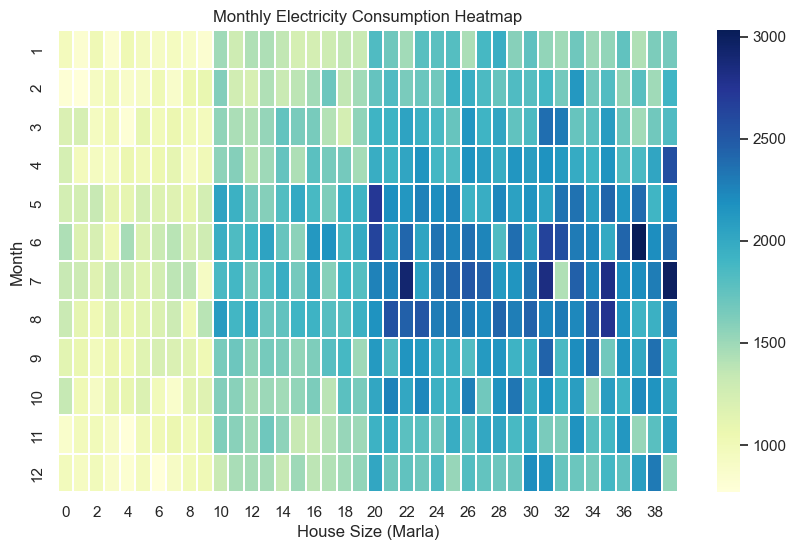

In [38]:
plt.figure(figsize=(10,6))
pivot_data = df.groupby(['month','house_size_marla'])['monthly_kwh'].mean().unstack()
sns.heatmap(pivot_data, cmap='YlGnBu', annot=False, linewidths=0.3)
plt.title('Monthly Electricity Consumption Heatmap')
plt.xlabel('House Size (Marla)')
plt.ylabel('Month')
plt.show()


C:\Users\mando\AppData\Local\Temp\ipykernel_6128\461111616.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('house_size_group')['monthly_kwh']


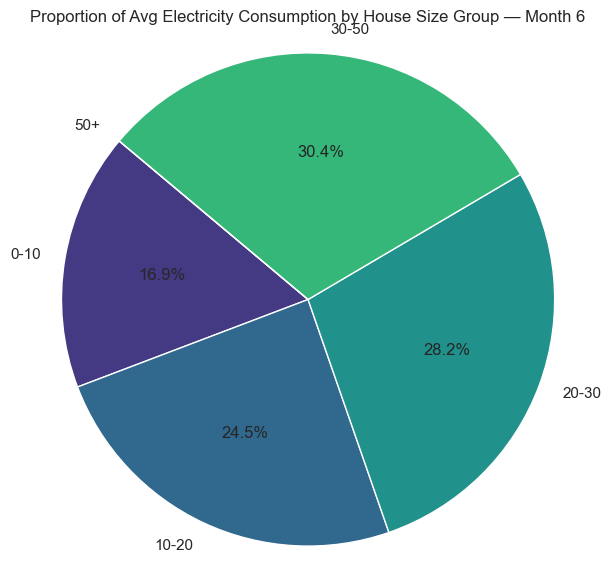

In [39]:
# Convert house_size_marla to numeric if not already
df['house_size_marla'] = pd.to_numeric(df['house_size_marla'], errors='coerce')

# Define bins and labels
bins = [0, 10, 20, 30, 50, 100]
labels = ['0-10', '10-20', '20-30', '30-50', '50+']

# Create house size group column
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)


month_to_plot = 6  # Example month

# Group by house size group
month_data = (df[df['month']==month_to_plot]
              .groupby('house_size_group')['monthly_kwh']
              .mean()
              .fillna(0))  # fill NaN for empty bins


plt.figure(figsize=(7,7))
plt.pie(
    month_data,
    labels=month_data.index,
    autopct=lambda p: ('{:.1f}%'.format(p)) if p > 0 else '',
    startangle=140,
    colors=sns.color_palette('viridis', len(month_data))
)
plt.title(f'Proportion of Avg Electricity Consumption by House Size Group — Month {month_to_plot}')
plt.axis('equal')
plt.show()


C:\Users\mando\AppData\Local\Temp\ipykernel_6128\475011637.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('house_size_group')['monthly_kwh']
C:\Users\mando\AppData\Local\Temp\ipykernel_6128\475011637.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


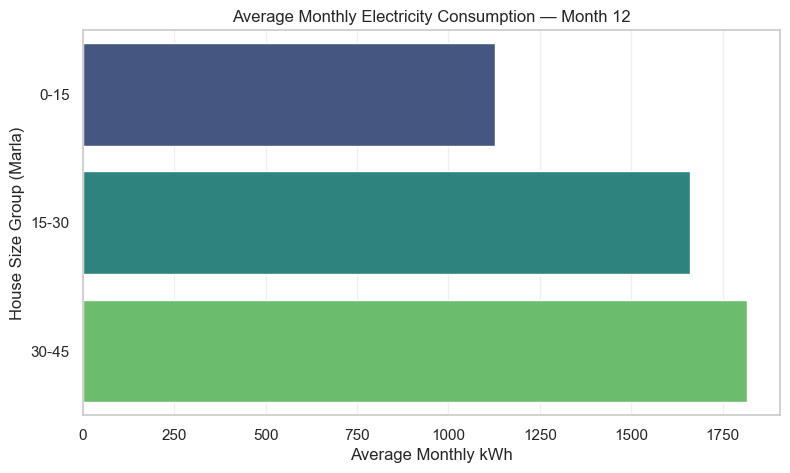

In [40]:
# Define month to plot
month_to_plot = 12  # change as needed

# Create bins for house sizes
bins = [0, 15, 30, 45]
labels = ['0-15', '15-30', '30-45']
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)

# Compute average monthly kWh for each house size group in the selected month
month_data = (df[df['month']==month_to_plot]
              .groupby('house_size_group')['monthly_kwh']
              .mean()
              .reindex(labels)  # ensure correct order
              .fillna(0)
              .reset_index())

# Plot
plt.figure(figsize=(9,5))
sns.barplot(
    y='house_size_group',
    x='monthly_kwh',
    data=month_data,
    palette='viridis',
    order=labels
)
plt.title(f'Average Monthly Electricity Consumption — Month {month_to_plot}')
plt.xlabel('Average Monthly kWh')
plt.ylabel('House Size Group (Marla)')
plt.grid(axis='x', alpha=0.3)
plt.show()


C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3702457402.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_month_group = df[df['house_size_group'].isin(top_groups)].groupby(


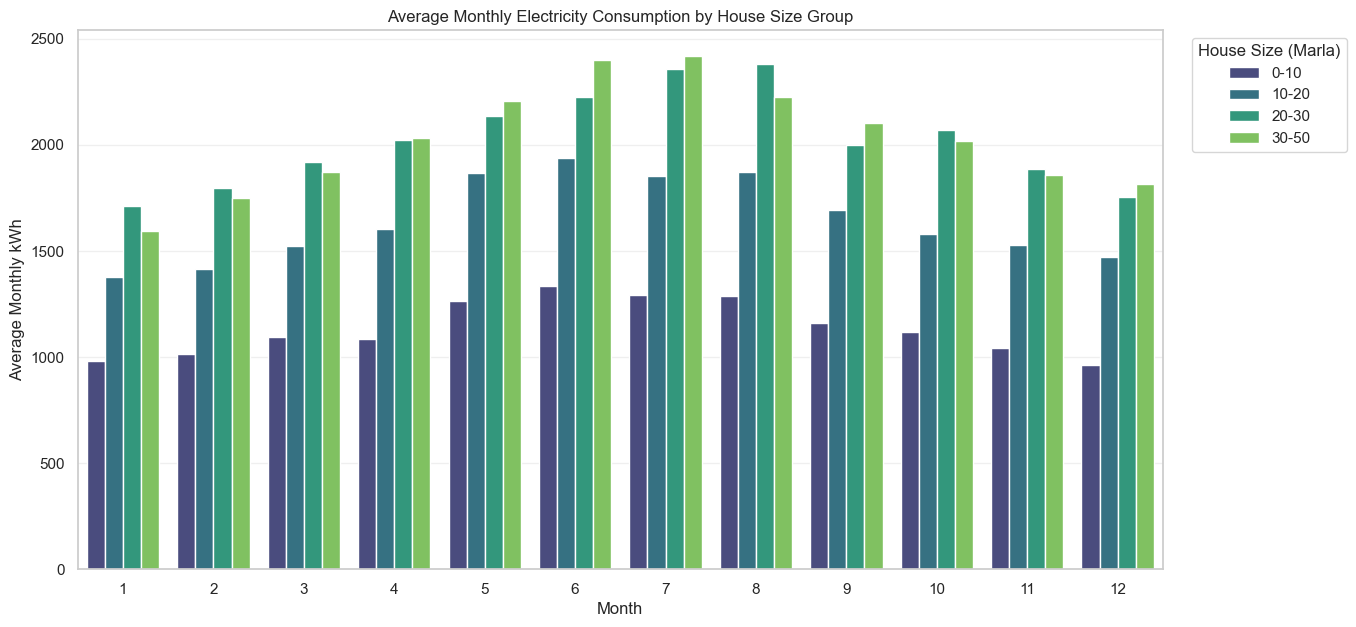

In [41]:
# ------------------- Define house size bins -------------------
bins = [0, 10, 20, 30, 50, 100]   # adjust as needed
labels = ['0-10', '10-20', '20-30', '30-50', '50+']

# Create a new column with house size groups
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)

# ------------------- Choose contiguous top groups -------------------
top_groups = ['0-10', '10-20', '20-30', '30-50']

# Prepare averaged data
avg_by_month_group = df[df['house_size_group'].isin(top_groups)].groupby(
    ['month', 'house_size_group']
)['monthly_kwh'].mean().reset_index()

# Ensure categorical order for house size groups and months
avg_by_month_group['house_size_group'] = pd.Categorical(
    avg_by_month_group['house_size_group'],
    categories=top_groups,
    ordered=True
)
avg_by_month_group = avg_by_month_group.sort_values(['month','house_size_group'])

# ------------------- Plot -------------------
plt.figure(figsize=(14,7))
sns.barplot(
    x='month',
    y='monthly_kwh',
    hue='house_size_group',
    data=avg_by_month_group,
    palette='viridis',
    hue_order=top_groups,
    order=range(1,13)  # months 1 - 12
)
plt.title('Average Monthly Electricity Consumption by House Size Group')
plt.xlabel('Month')
plt.ylabel('Average Monthly kWh')
plt.legend(title='House Size (Marla)', bbox_to_anchor=(1.02,1), loc='upper left')
plt.grid(alpha=0.3, axis='y')
plt.show()


C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3758111995.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby(['month', 'house_size_group'])['monthly_kwh'].mean().reset_index()
C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3758111995.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3758111995.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\mando\AppData\Local\Temp\ipykernel_6128\3758111995.py:29: FutureWarning: 

Pass

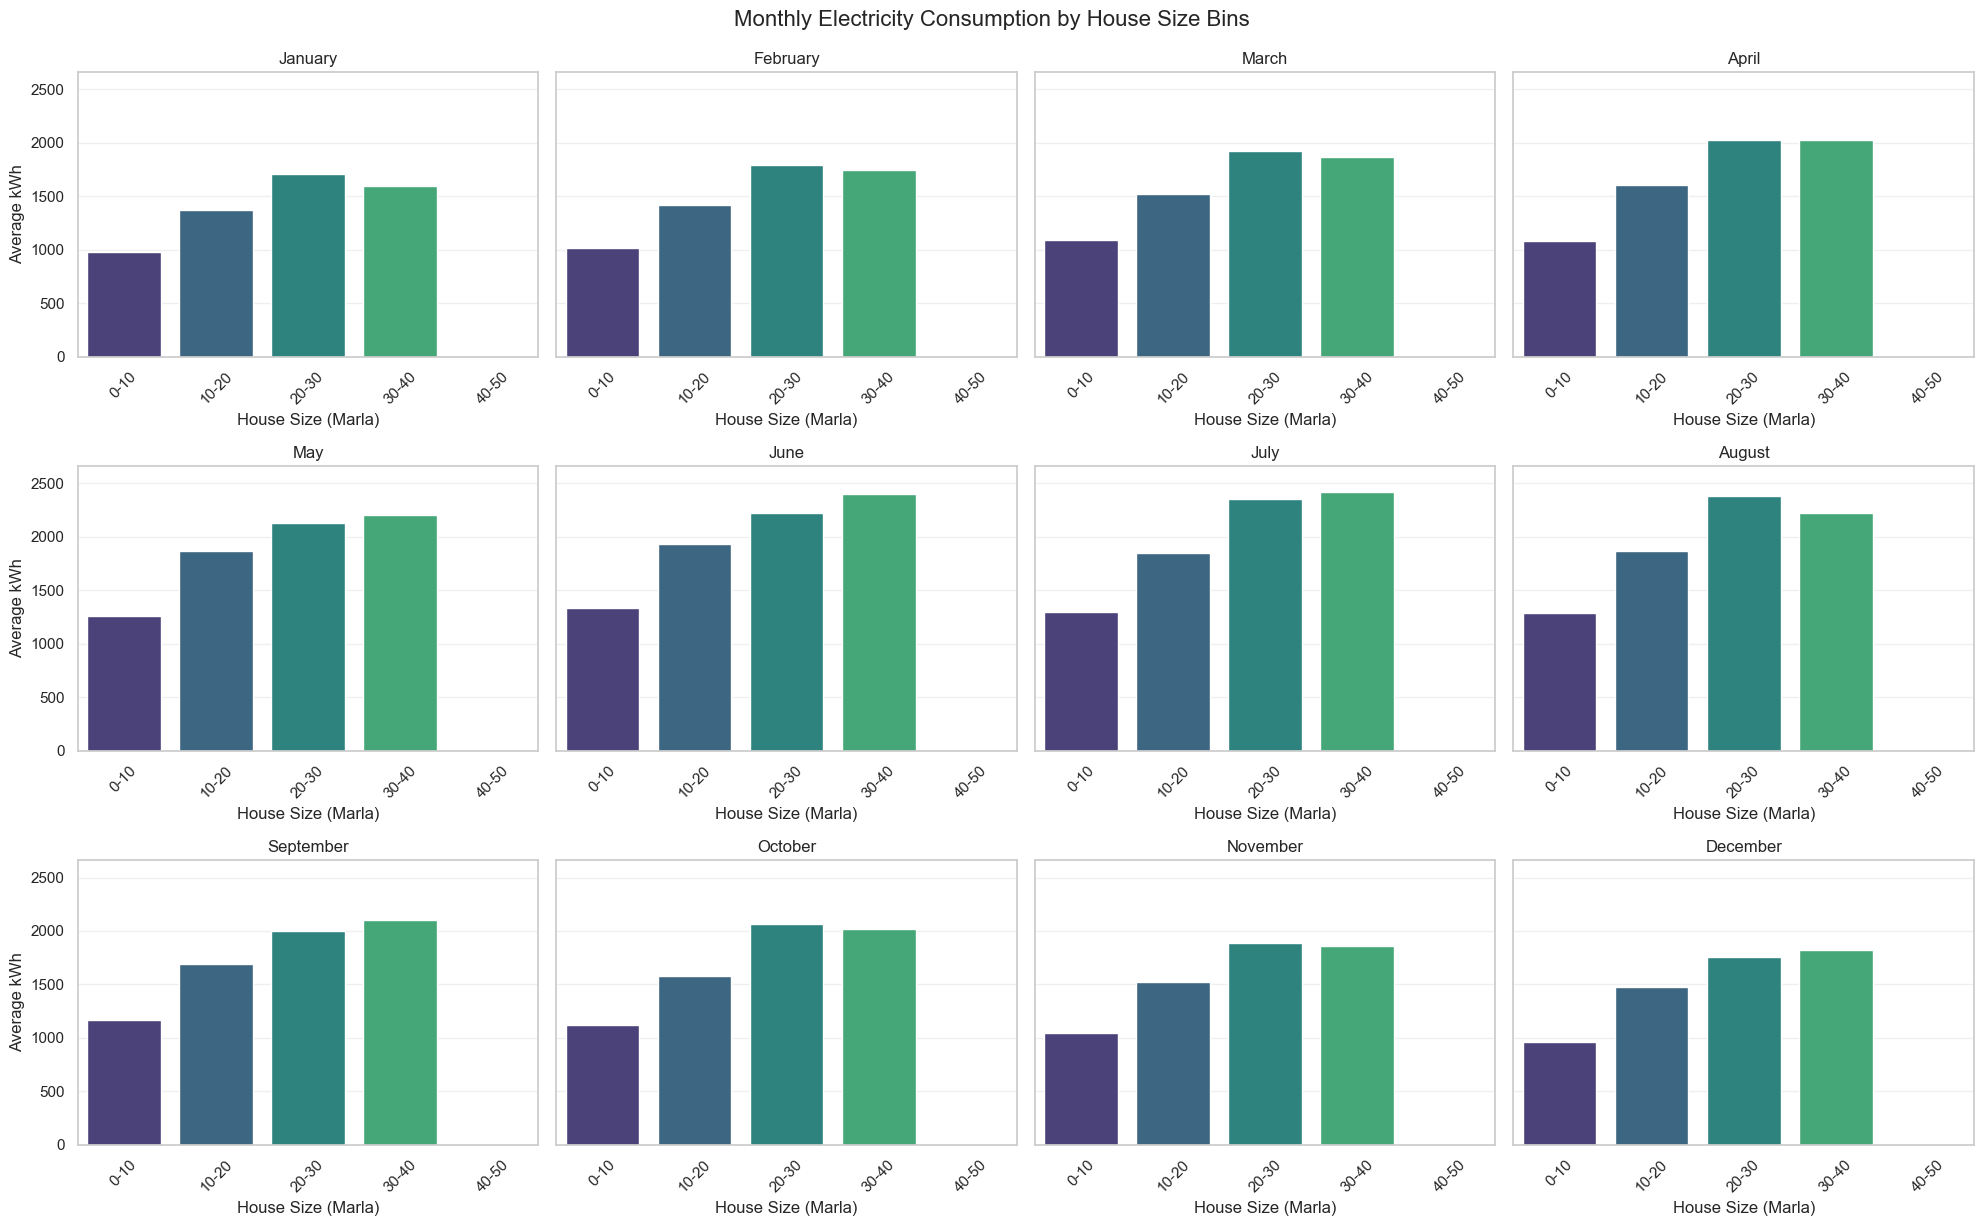

In [42]:
# ------------------- Define house size bins -------------------
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10','10-20','20-30','30-40','40-50']
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)

# ------------------- Compute monthly averages -------------------
monthly_avg = df.groupby(['month', 'house_size_group'])['monthly_kwh'].mean().reset_index()
monthly_avg['house_size_group'] = pd.Categorical(monthly_avg['house_size_group'], categories=labels, ordered=True)

# ------------------- Set up figure -------------------
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes = axes.flatten()

# Max value for consistent Y-axis across all subplots
y_max = monthly_avg['monthly_kwh'].max() * 1.1

# ------------------- Plot each month -------------------
for month in range(1, 13):
    ax = axes[month-1]
    month_data = monthly_avg[monthly_avg['month'] == month]
    
    if month_data.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45)
        ax.set_ylim(0, y_max)
        continue
    
    sns.barplot(
        x='house_size_group',
        y='monthly_kwh',
        data=month_data,
        palette='viridis',
        ax=ax
    )
    ax.set_title(calendar.month_name[month], fontsize=12)
    ax.set_xlabel("House Size (Marla)")
    ax.set_ylabel("Average kWh")
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.suptitle("Monthly Electricity Consumption by House Size Bins", fontsize=16, y=1.02)
plt.show()



C:\Users\mando\AppData\Local\Temp\ipykernel_6128\1371255428.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_data = df[df['month'] == month_to_plot].groupby('house_size_group')['monthly_kwh'].mean().reset_index()
C:\Users\mando\AppData\Local\Temp\ipykernel_6128\1371255428.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


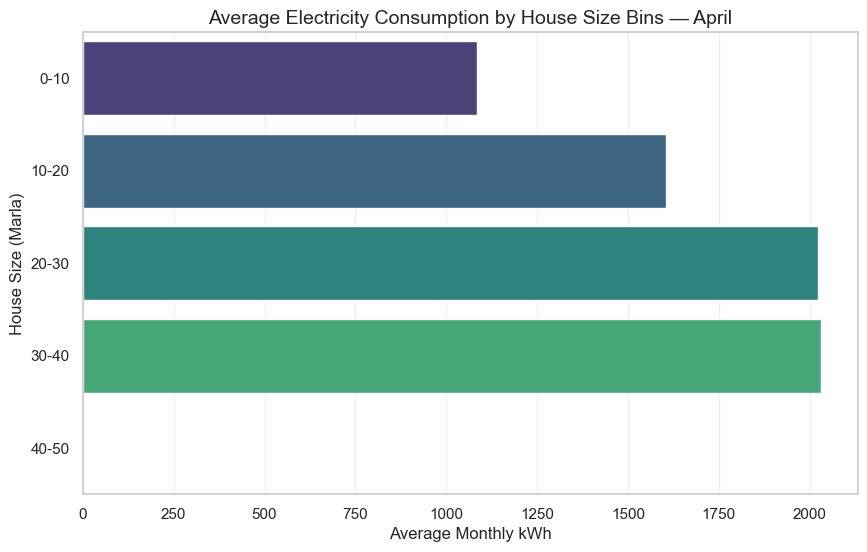

In [ ]:
# ------------------- Define house size bins -------------------
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10','10-20','20-30','30-40','40-50']
df['house_size_group'] = pd.cut(df['house_size_marla'], bins=bins, labels=labels, include_lowest=True)

# ------------------- Select month to plot -------------------
month_to_plot = 4  # change as needed (1-12)
month_data = df[df['month'] == month_to_plot].groupby('house_size_group')['monthly_kwh'].mean().reset_index()

# Sort house size bins
month_data['house_size_group'] = pd.Categorical(month_data['house_size_group'], categories=labels, ordered=True)
month_data = month_data.sort_values('house_size_group')

# ------------------- Plot -------------------
plt.figure(figsize=(10,6))
sns.barplot(
    x='monthly_kwh',
    y='house_size_group',
    data=month_data,
    palette="viridis"
)

plt.title(f"Average Electricity Consumption by House Size Bins — {pd.to_datetime(month_to_plot, format='%m').strftime('%B')}", fontsize=14)
plt.xlabel("Average Monthly kWh", fontsize=12)
plt.ylabel("House Size (Marla)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
# Save Random Forest Model
with open("rf_electricity_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("🎉 Random Forest Model saved successfully as rf_electricity_model.pkl")

🎉 Random Forest Model saved successfully as rf_electricity_model.pkl
